# Network Chart

A network chart shows who connects to whom: each node is an entity, each edge a relationship, and the picture answers *who is central, which clusters form, and who bridges them*. This guide shows how to create network charts with the [datachart.charts.NetworkChart](../../../references/charts/networkchart/#datachart.charts.NetworkChart) function, starting with the basics and building up to worked examples on real data.

Looking for a specific customization? Jump straight to the [quick reference](#customizing-the-network-chart), which maps common tasks to the parameter or style attribute that does the job.

In [1]:
from datachart.charts import NetworkChart

## Basics

The examples in this guide share one dataset: the marriage ties among fifteen leading families of Florence around 1430, the years in which the Medici rose to power (source: John Padgett's Florentine families data, from Padgett and Ansell, *Robust Action and the Rise of the Medici, 1400-1434*, American Journal of Sociology, 1993). An edge joins two families linked by a marriage. The data lives in a hidden cell: `marriages` holds the twenty ties, `TIES` counts the ties of each family, `STEPS` counts the marriages between each family and the Medici, and `FAMILIES` lists the families in that order. The network has a famous story in it, and the customizations below tell it: the Medici sat in the middle of the network, and some families could reach the others only through them.

In [2]:
from collections import Counter

# marriage ties among Florentine families around 1430 (Padgett and Ansell, 1993)
MARRIAGES = [
    ("Acciaiuoli", "Medici"),
    ("Medici", "Barbadori"),
    ("Medici", "Ridolfi"),
    ("Medici", "Tornabuoni"),
    ("Medici", "Albizzi"),
    ("Medici", "Salviati"),
    ("Castellani", "Peruzzi"),
    ("Castellani", "Strozzi"),
    ("Castellani", "Barbadori"),
    ("Salviati", "Pazzi"),
    ("Peruzzi", "Strozzi"),
    ("Peruzzi", "Bischeri"),
    ("Strozzi", "Ridolfi"),
    ("Strozzi", "Bischeri"),
    ("Ridolfi", "Tornabuoni"),
    ("Tornabuoni", "Guadagni"),
    ("Albizzi", "Ginori"),
    ("Albizzi", "Guadagni"),
    ("Bischeri", "Guadagni"),
    ("Guadagni", "Lamberteschi"),
]
marriages = {"edges": [{"source": a, "target": b} for a, b in MARRIAGES]}

# the number of marriage ties of each family
TIES = Counter(family for pair in MARRIAGES for family in pair)

# the number of marriages between each family and the Medici (breadth-first search)
STEPS = {"Medici": 0}
frontier = {"Medici"}
while frontier:
    reached = set()
    for a, b in MARRIAGES + [(b, a) for a, b in MARRIAGES]:
        if a in frontier and b not in STEPS:
            STEPS[b] = STEPS[a] + 1
            reached.add(b)
    frontier = reached
FAMILIES = sorted(STEPS, key=lambda family: (STEPS[family], family))

The data is a dictionary with an `edges` list. Each edge names the two nodes it joins by their ids, a `source` and a `target`:

In [3]:
marriages["edges"][:3]

[{'source': 'Acciaiuoli', 'target': 'Medici'},
 {'source': 'Medici', 'target': 'Barbadori'},
 {'source': 'Medici', 'target': 'Ridolfi'}]

The nodes can be listed too, as a `nodes` list of dictionaries with a unique `id`. Without the list, as here, the nodes are read from the edges in the order they are first named. Everything else is optional: a node's `label` (the id by default), `size`, `group` and `emphasis`, and an edge's `weight`; the sections below show each one. An edge that names an unknown node or joins a node to itself, a repeated id, and a `size` or `weight` that is not above zero raise a `ValueError`.

**Basic example.** Only the `data` argument is required. A force-directed layout places the nodes, so families joined by a marriage sit close and every pair pushes apart, and curved edges join them:

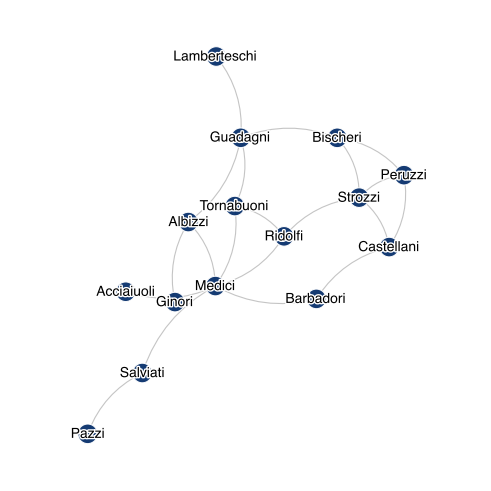

In [4]:
NetworkChart(
    # add the data to the chart
    data=marriages
).show()

## Customizing the Network Chart

Every customization is either a keyword argument of `NetworkChart`, a key of the node and edge records, or a `plot_network_*` attribute of its `style` dictionary. The table maps common tasks to the one you need and links to the subsection that shows it.

| I want to…                                  | Use                                                                     | See |
| :------------------------------------------ | :---------------------------------------------------------------------- | :-- |
| add a title and resize the figure           | `title`, `figsize`                                                      | [Title and figure size](#title-and-figure-size) |
| move or rename the node labels              | `label_position`, `"label"` on the nodes                                | [Node labels](#node-labels) |
| place the nodes another way                 | `layout`, `seed`                                                        | [Layouts](#layouts) |
| put every node where I say                  | `layout=NETWORK_LAYOUT.FIXED`, `"x"` and `"y"` on the nodes             | [Layouts](#layouts) |
| draw a large network                        | aggregate first; `NETWORK_LAYOUT.CIRCULAR` past ~1,000 nodes            | [Large networks](#large-networks) |
| show the direction of the edges             | `directed`                                                              | [Directed edges](#directed-edges) |
| size the edges and the nodes by a value     | `"weight"` on the edges, `"size"` on the nodes                          | [Edge weights and node sizes](#edge-weights-and-node-sizes) |
| let heavy edges pull their nodes together   | `layout=NETWORK_LAYOUT.WEIGHTED`                                        | [Edge weights and node sizes](#edge-weights-and-node-sizes) |
| color the nodes by a category               | `"group"` on the nodes, `show_legend`, `legend`                         | [Groups and the legend](#groups-and-the-legend) |
| cluster the nodes by their group            | `layout=NETWORK_LAYOUT.GROUPED`                                         | [Groups and the legend](#groups-and-the-legend) |
| highlight or mute a node                    | `"emphasis"` on the nodes                                               | [Emphasis](#emphasis) |
| highlight the nodes that match a rule       | `emphasis_rule`                                                         | [Emphasis](#emphasis) |
| write the weights on the edges              | `show_values`, `value_format`                                           | [Edge values](#edge-values) |
| draw straight edges, or bow them more       | `style={"plot_network_edge_style": ..., "plot_network_edge_curve": ...}` | [Node and edge style](#node-and-edge-style) |
| change the node markers or colors           | `style={"plot_network_node_marker": ..., "plot_network_node_color": ...}` | [Node and edge style](#node-and-edge-style) |
| put a note on the chart                     | `texts`                                                                 | [Text annotations](#text-annotations) |
| draw several networks side by side          | `data` as a list of networks, `subtitle`, `max_cols`                    | [Subplots](#subplots) |
| arrange a network next to other charts      | `Grid`                                                                  | [Composing network charts](#composing-network-charts) |
| restyle every chart at once                 | `config.set_theme`                                                      | [Themes](#themes) |
| save the chart to a file                    | `save_figure`                                                           | [Saving Figures](../../utility/saving/) guide |

The parameters that accept a constant, with the class in [datachart.constants](../../../references/constants/) that lists its values:

| Parameter | Constant |
| :-- | :-- |
| `layout` | [`NETWORK_LAYOUT`](../../../references/constants/#datachart.constants.NETWORK_LAYOUT) |
| `label_position` | [`NODE_LABEL_POSITION`](../../../references/constants/#datachart.constants.NODE_LABEL_POSITION) |
| `value_format` | [`VALUE_FORMAT`](../../../references/constants/#datachart.constants.VALUE_FORMAT) |
| `legend={"location": ..., "alignment": ...}` | [`LEGEND_LOCATION`](../../../references/constants/#datachart.constants.LEGEND_LOCATION), [`LEGEND_ALIGN`](../../../references/constants/#datachart.constants.LEGEND_ALIGN) |
| `figsize` | [`FIG_SIZE`](../../../references/constants/#datachart.constants.FIG_SIZE) |

The full list of style attributes is in the [datachart.typings.NetworkStyleAttrs](../../../references/charts/networkchart/#datachart.typings.NetworkStyleAttrs) type; the full list of parameters is in the [datachart.charts.NetworkChart](../../../references/charts/networkchart/#datachart.charts.NetworkChart) reference.

### Title and figure size

A network has no axes to label, so the title carries the whole message: `title` says what the nodes and the edges are. The layout always keeps a square aspect, so a wide figure leaves empty space beside the drawing rather than stretching it; `figsize` takes a `(width, height)` tuple in inches or one of the [FIG_SIZE](../../../references/constants/#datachart.constants.FIG_SIZE) presets, and `FIG_SIZE.SQUARE` fits a network best.

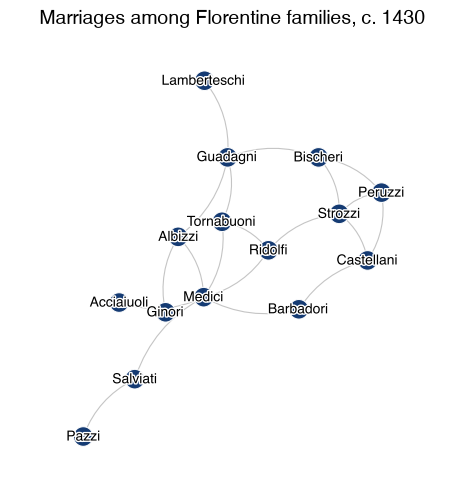

In [5]:
from datachart.constants import FIG_SIZE

NetworkChart(
    data=marriages,
    # say what the nodes and the edges are
    title="Marriages among Florentine families, c. 1430",
    # a square figure for a square layout
    figsize=FIG_SIZE.SQUARE,
).show()

### Node labels

Family names are longer than the markers, and printed on the node, as in the basic example, they run over the edges and over each other. `label_position` moves them, using [NODE_LABEL_POSITION](../../../references/constants/#datachart.constants.NODE_LABEL_POSITION): `CENTER` (the default) prints on the marker, `ABOVE` prints above it like a place name on a map, and `BEST` picks the spot beside each marker with the least overlap. A node's `label` key changes what is printed without changing its id, and an empty label prints nothing. The example prints the names above the markers, where they stay clear of the edges, and adds each family's number of ties to its label. The rest of the guide prints the names above the markers too.

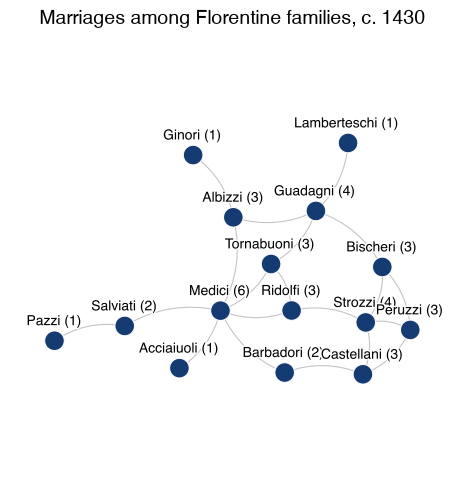

In [6]:
from datachart.constants import NODE_LABEL_POSITION

labeled = {
    # the number of ties in the label; the edges still use the id
    "nodes": [{"id": family, "label": f"{family} ({TIES[family]})"} for family in FAMILIES],
    "edges": marriages["edges"],
}

NetworkChart(
    data=labeled,
    # the names above the markers
    label_position=NODE_LABEL_POSITION.ABOVE,
    title="Marriages among Florentine families, c. 1430",
    figsize=FIG_SIZE.SQUARE,
).show()

### Layouts

Where a node sits is not data: the layout decides it, and the layout decides what the picture seems to say. `layout` picks the rule from [NETWORK_LAYOUT](../../../references/constants/#datachart.constants.NETWORK_LAYOUT), and each one tells the truth about something different.

`SPRING`, the default, pulls linked nodes together and pushes every pair apart, so tightly knit groups end up close and a hub ends up in the middle. It is the layout for the question *what is connected to what*. The distances are only approximate, and the arrangement is one of many: `seed` (0 by default) picks it, the same seed always draws the same picture, and another seed turns and flips it. Read the connections, never the exact positions. The two drawings below are the same network, and in both the Medici sit between two halves of it.

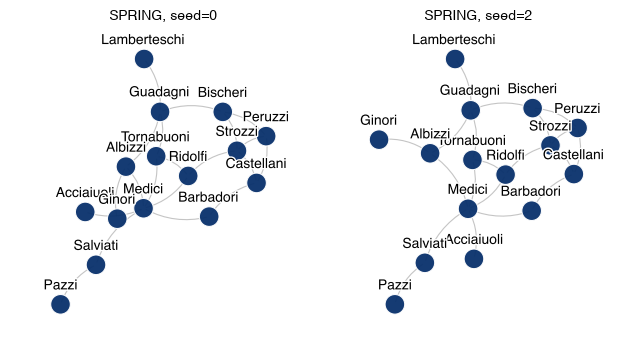

In [7]:
from datachart.constants import NETWORK_LAYOUT
from datachart.utils import Grid

Grid(
    [[
        NetworkChart(marriages, label_position=NODE_LABEL_POSITION.ABOVE, title="SPRING, seed=0"),
        # another arrangement of the same network
        NetworkChart(marriages, seed=2, label_position=NODE_LABEL_POSITION.ABOVE, title="SPRING, seed=2"),
    ]],
    figsize=(6.3, 3.4),
).show()

`CIRCULAR` spaces the nodes evenly on a circle in input order, starting at the top, and invents no clusters, so it is honest when the order of the nodes means something or when the picture must be the same every time. Listing the families from the most ties to the fewest puts the hubs at the top. `FIXED` places each node at its own `x` and `y` in the 0-1 layout space; it tells the truth when a position means something, such as a place on a map or a level in a hierarchy, and a node without `x` and `y` raises a `ValueError`. Here each family sits on a row by its number of marriages from the Medici, so the height of a node means something:

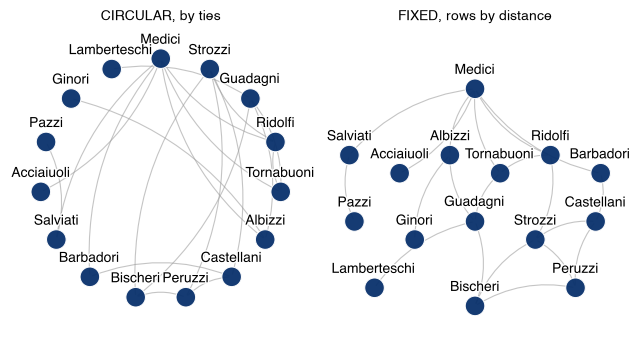

In [8]:
# the families from the most ties to the fewest, for the circle
by_ties = {
    "nodes": [{"id": family} for family in sorted(TIES, key=TIES.get, reverse=True)],
    "edges": marriages["edges"],
}

# one row per marriage step from the Medici, ordered to limit the crossings
ROWS = [
    ["Medici"],
    ["Salviati", "Acciaiuoli", "Albizzi", "Tornabuoni", "Ridolfi", "Barbadori"],
    ["Pazzi", "Ginori", "Guadagni", "Strozzi", "Castellani"],
    ["Lamberteschi", "Bischeri", "Peruzzi"],
]
levels = {
    "nodes": [
        # every other family a little lower, so the names do not collide
        {"id": family, "x": (i + 0.5) / len(row), "y": 0.8 - 0.22 * step - 0.06 * (i % 2)}
        for step, row in enumerate(ROWS)
        for i, family in enumerate(row)
    ],
    "edges": marriages["edges"],
}

Grid(
    [[
        # the nodes on a circle, in input order
        NetworkChart(
            by_ties,
            layout=NETWORK_LAYOUT.CIRCULAR,
            label_position=NODE_LABEL_POSITION.ABOVE,
            title="CIRCULAR, by ties",
        ),
        # every node at its own x and y
        NetworkChart(
            levels,
            layout=NETWORK_LAYOUT.FIXED,
            label_position=NODE_LABEL_POSITION.ABOVE,
            title="FIXED, rows by distance",
        ),
    ]],
    figsize=(6.3, 3.4),
).show()

Two more layouts let the data shape the picture: `WEIGHTED` lets heavy edges pull harder (see [Edge weights and node sizes](#edge-weights-and-node-sizes)), and `GROUPED` clusters the nodes by their group (see [Groups and the legend](#groups-and-the-legend)). `layout` and `seed` apply to every network in a figure, which is why the comparisons above draw separate figures and arrange them with [Grid](#composing-network-charts).

### Large networks

A network chart is meant for a network a reader can follow, and the drawing cost sets a ceiling well before the readable one. Every edge is its own curved patch, a few milliseconds to draw and as many again to save, and the spring layouts weigh every pair of nodes, so their cost grows with the square of the node count. Measured on a laptop, these sizes draw without a problem:

| Layout                                    | Nodes        | Edges         | Time to draw and save |
| :---------------------------------------- | :----------- | :------------ | :-------------------- |
| `SPRING` (default), `WEIGHTED`, `GROUPED` | up to ~1,000 | up to ~3,000  | a few seconds         |
| `CIRCULAR`, `FIXED`                       | up to ~5,000 | up to ~15,000 | under a minute        |

Past those, the spring layouts slow down first: 2,000 nodes take about half a minute, 5,000 several minutes and over a gigabyte of memory. Nothing is enforced, but a picture that dense reads as a hairball anyway. Aggregate the nodes (one node per group, one edge per pair of groups, weighted by the count) or keep only the heaviest edges before drawing, and switch to `CIRCULAR` or `FIXED` past a thousand nodes.

The example does that with an illustrative code base, generated with a seeded generator: 3,000 modules in 120 packages owned by six teams, and 15,000 random imports. It is collapsed into one node per package, colored by team and sized by the imports crossing its border, and one edge per pair of packages with at least five imports between them. The labels are empty, since 120 package names would bury the drawing.

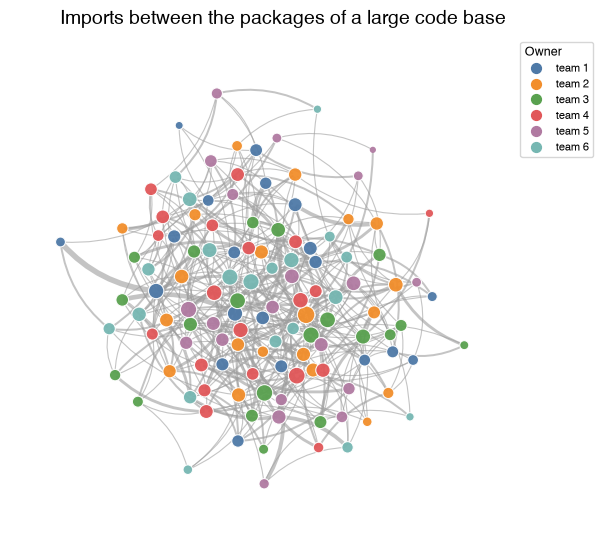

In [9]:
import random

rng = random.Random(0)
N_MODULES, N_PACKAGES, N_IMPORTS = 3000, 120, 15000
package = {f"m{i}": f"pkg{i % N_PACKAGES}" for i in range(N_MODULES)}
team = {f"pkg{p}": f"team {p // 20 + 1}" for p in range(N_PACKAGES)}
module_imports = [
    (f"m{rng.randrange(N_MODULES)}", f"m{rng.randrange(N_MODULES)}") for _ in range(N_IMPORTS)
]

# one edge per pair of packages with at least five imports between them
crossing = Counter(
    tuple(sorted((package[s], package[t]))) for s, t in module_imports if package[s] != package[t]
)
edges = [{"source": a, "target": b, "weight": n} for (a, b), n in crossing.items() if n >= 5]

# a package's size is the number of imports crossing its border
traffic = Counter()
for edge in edges:
    traffic[edge["source"]] += edge["weight"]
    traffic[edge["target"]] += edge["weight"]
nodes = [{"id": pkg, "label": "", "group": owner, "size": traffic[pkg]} for pkg, owner in team.items()]

NetworkChart(
    data={"nodes": nodes, "edges": edges},
    show_legend=True,
    legend={"title": "Owner"},
    title="Imports between the packages of a large code base",
    figsize=(6.3, 5.4),
    # smaller markers keep 120 nodes apart
    style={"plot_network_node_size_min": 20, "plot_network_node_size_max": 160},
).show()

### Directed edges

A marriage joins two families both ways, but many relationships have a direction: who imports whom, who pays whom, who follows whom. `directed=True` ends each edge in an arrowhead at its target, and an edge and its reverse draw as two arrows bowing to either side; without it an edge and its reverse draw as one line. The marriages have no direction, so this section switches dataset: `imports`, defined in a hidden cell, is an illustrative dependency graph of a small web service. Each module has a size in lines of code, and each edge points from the importing module to the imported one, weighted by the number of names it imports; `import_edges` holds the same edges without the weights.

In [10]:
# an illustrative web service: module -> lines of code
MODULES = {
    "app": 620, "cli": 340, "api": 910, "auth": 480, "jobs": 260,
    "models": 1150, "storage": 730, "config": 190, "utils": 410,
}
# (importing module, imported module, names imported)
IMPORTS = [
    ("app", "api", 12), ("app", "auth", 4), ("app", "config", 2),
    ("cli", "api", 6), ("cli", "jobs", 3), ("cli", "config", 2),
    ("api", "models", 15), ("api", "auth", 5), ("api", "storage", 7),
    ("auth", "models", 6), ("auth", "utils", 3),
    ("jobs", "storage", 4), ("jobs", "models", 5),
    ("models", "utils", 8),
    ("storage", "config", 3), ("storage", "utils", 4),
]
imports = {
    "nodes": [{"id": module, "size": lines} for module, lines in MODULES.items()],
    "edges": [{"source": s, "target": t, "weight": n} for s, t, n in IMPORTS],
}
import_edges = {"edges": [{"source": s, "target": t} for s, t, _ in IMPORTS]}

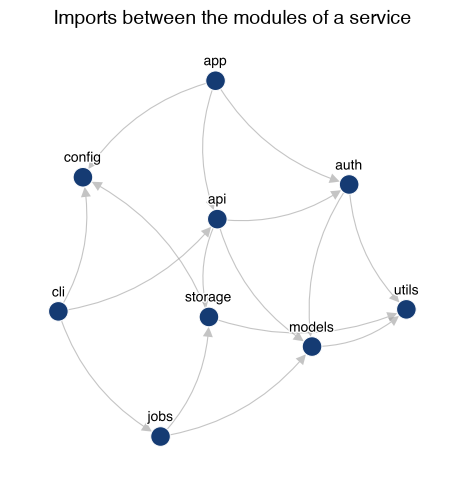

In [11]:
NetworkChart(
    data=import_edges,
    # arrowheads from the importing module to the imported one
    directed=True,
    label_position=NODE_LABEL_POSITION.ABOVE,
    title="Imports between the modules of a service",
    figsize=FIG_SIZE.SQUARE,
).show()

### Edge weights and node sizes

A plain edge says two nodes are linked; a weighted one says how strongly. An edge's `weight` sets its width, linearly between `plot_network_edge_width_min` and `plot_network_edge_width_max` over the weights in the chart, and an edge without one draws at the minimum. A node's `size` sets its marker area, by square root between `plot_network_node_size_min` and `plot_network_node_size_max`, so a node four times the size draws a marker twice as wide; a node without one draws at `plot_network_node_size`. In `imports` the width of an import is the number of names it pulls in and a module's marker grows with its lines of code, so the heavy path from `api` to `models` stands out.

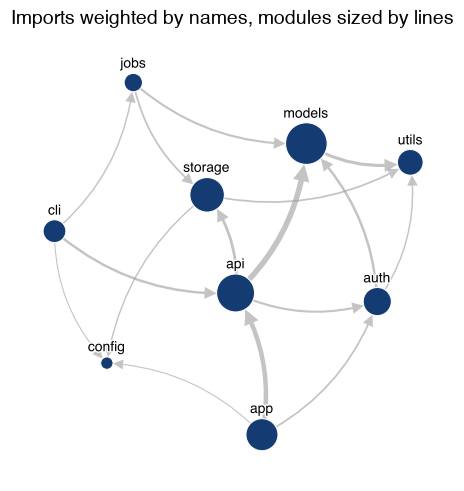

In [12]:
NetworkChart(
    # the edges carry a weight, the nodes a size
    data=imports,
    directed=True,
    label_position=NODE_LABEL_POSITION.ABOVE,
    title="Imports weighted by names, modules sized by lines",
    figsize=FIG_SIZE.SQUARE,
).show()

Under `SPRING` a weight is only drawn, it never moves a node. `NETWORK_LAYOUT.WEIGHTED` lets it: the lightest edge pulls at a tenth of the plain pull and the heaviest at three times, so modules that share many names draw close and loosely coupled ones drift apart. The exact rule is in the [NETWORK_LAYOUT](../../../references/constants/#datachart.constants.NETWORK_LAYOUT) reference.

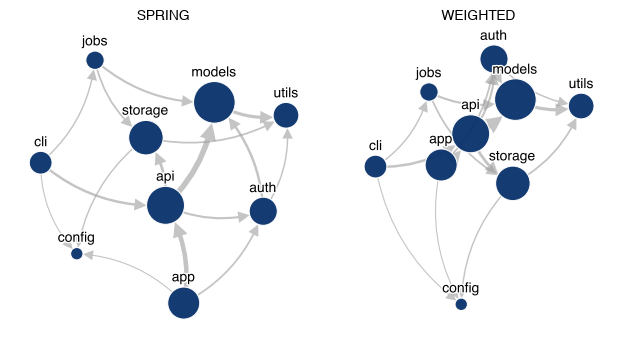

In [13]:
Grid(
    [[
        NetworkChart(imports, directed=True, label_position=NODE_LABEL_POSITION.ABOVE, title="SPRING"),
        # heavy imports pull their modules close
        NetworkChart(
            imports,
            directed=True,
            layout=NETWORK_LAYOUT.WEIGHTED,
            label_position=NODE_LABEL_POSITION.ABOVE,
            title="WEIGHTED",
        ),
    ]],
    figsize=(6.3, 3.4),
).show()

### Groups and the legend

Coloring the nodes by a category shows whether the connections follow it. A node's `group` colors it: the groups take the palette colors in the order they are first seen, and a node without a group draws in the edge color. `show_legend` names the groups beside the drawing, and `legend` sets its `title`, `location` ([LEGEND_LOCATION](../../../references/constants/#datachart.constants.LEGEND_LOCATION)), columns and alignment ([LegendSettingAttrs](../../../references/typings/#datachart.typings.LegendSettingAttrs)). Grouping the families by their number of marriages from the Medici shows how far the Medici reach: six families in one step, and every family within three.

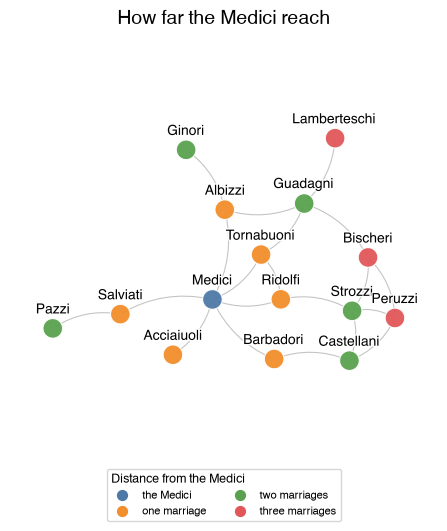

In [14]:
from datachart.constants import LEGEND_LOCATION

STEP_NAMES = ["the Medici", "one marriage", "two marriages", "three marriages"]
by_step = {
    # in step order, so the legend lists the groups in order
    "nodes": [{"id": family, "group": STEP_NAMES[STEPS[family]]} for family in FAMILIES],
    "edges": marriages["edges"],
}

NetworkChart(
    data=by_step,
    label_position=NODE_LABEL_POSITION.ABOVE,
    # name the groups, under a title, below the drawing
    show_legend=True,
    legend={"title": "Distance from the Medici", "location": LEGEND_LOCATION.OUTSIDE_BOTTOM, "ncols": 2},
    title="How far the Medici reach",
    figsize=(4.8, 5.2),
).show()

`NETWORK_LAYOUT.GROUPED` also places the nodes by group: each group is laid out on its own, the groups are then arranged by the edges between them, and a translucent disc in the group color marks each cluster (`plot_network_group_alpha` sets its alpha, `0` removes it). It pays off when most edges run inside the groups, like the teams in [Example 1](#example-1-who-reviews-whose-code-undirected-grouped-layout-sizes-and-a-highlight). The families above are grouped by distance, so their ties run between the groups, and the spring layout serves them better.

### Emphasis

A network chart usually makes one point about a few nodes. A node's `emphasis` key sets its role, one of the [EMPHASIS](../../../references/constants/#datachart.constants.EMPHASIS) roles: `"highlight"` strokes the node's border, `"background"` mutes the node, its label and every edge touching it. The roles are explicit: highlighting one node does not mute the others, and the `emphasis` argument of the function is not supported. The example shows the Medici as a bridge: it highlights them and mutes every family that stays connected without them, so what is left in color are the three families that reach the rest of the network only through the Medici.

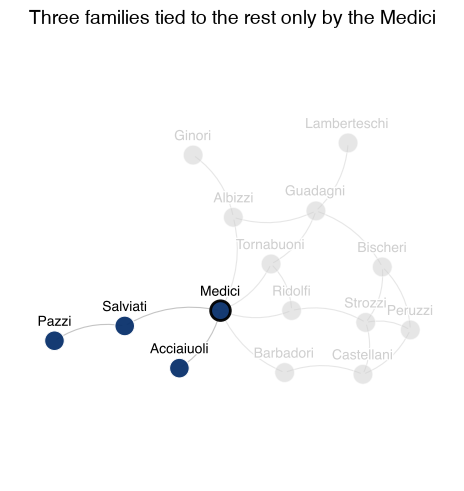

In [15]:
from datachart.constants import EMPHASIS

# the families that reach the others only through the Medici
THROUGH_MEDICI = {"Acciaiuoli", "Salviati", "Pazzi"}


def role(family):
    if family == "Medici":
        return EMPHASIS.HIGHLIGHT
    return None if family in THROUGH_MEDICI else EMPHASIS.BACKGROUND


bridge = {
    "nodes": [{"id": family, "emphasis": role(family)} for family in FAMILIES],
    "edges": marriages["edges"],
}

NetworkChart(
    data=bridge,
    label_position=NODE_LABEL_POSITION.ABOVE,
    title="Three families tied to the rest only by the Medici",
    figsize=FIG_SIZE.SQUARE,
).show()

`emphasis_rule` picks the nodes from the data instead: a one-key rule, `{"top": n}` or `{"bottom": n}` by rank, `{"above": v}` or `{"below": v}` (strict), or `{"between": (lo, hi)}` (inclusive), read against each node's `size`. The nodes that match are highlighted and the rest muted; a node without a `size` raises a `ValueError`, and a node's own `emphasis` key wins over the rule. Sizing each family by its number of ties and highlighting the top three shows that the Medici had more marriages than anyone, with the Strozzi and the Guadagni behind them. The [Highlighting](../../styling/highlighting/) guide covers emphasis on every chart.

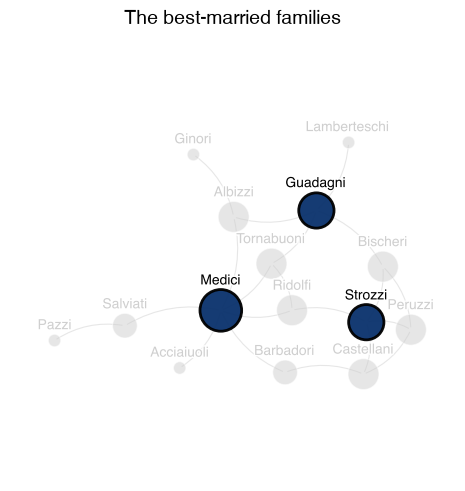

In [16]:
by_ties_sized = {
    "nodes": [{"id": family, "size": TIES[family]} for family in FAMILIES],
    "edges": marriages["edges"],
}

NetworkChart(
    data=by_ties_sized,
    label_position=NODE_LABEL_POSITION.ABOVE,
    # the three families with the most ties
    emphasis_rule={"top": 3},
    title="The best-married families",
    figsize=FIG_SIZE.SQUARE,
).show()

### Edge values

Widths show which edges are heavy, but not by how much. `show_values` writes each edge's weight at its midpoint, on the bow of a curved edge and behind the same halo as the labels, and `value_format` formats it: a [VALUE_FORMAT](../../../references/constants/#datachart.constants.VALUE_FORMAT) constant or any `"{x:.1f}"`, `"{:.1f}%"` or `"%g"` style string. An edge without a weight gets no value. On `imports` the values give the number of names behind each import.

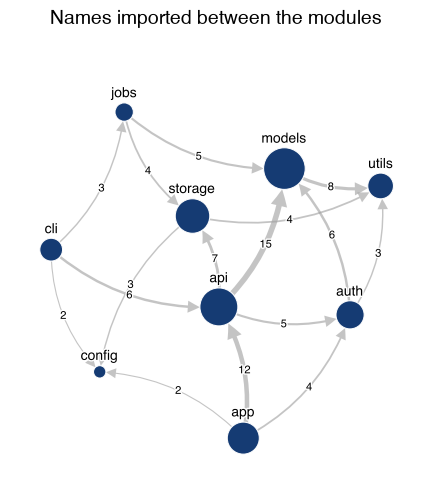

In [17]:
from datachart.constants import VALUE_FORMAT

NetworkChart(
    data=imports,
    directed=True,
    label_position=NODE_LABEL_POSITION.ABOVE,
    # write the number of imported names on the edges
    show_values=True,
    value_format=VALUE_FORMAT.INTEGER,
    title="Names imported between the modules",
    figsize=FIG_SIZE.SQUARE,
).show()

### Node and edge style

The `style` dictionary sets the look of the nodes and the edges; the attributes are listed in [datachart.typings.NetworkStyleAttrs](../../../references/charts/networkchart/#datachart.typings.NetworkStyleAttrs), and any attribute left out keeps the value of the active theme. The nodes take the `plot_network_node_*` keys: the color (which overrides the palette), alpha, marker, stroke and the areas the sizes map onto. The edges take their color, alpha and width range, and `plot_network_label_halo_width` sets the white halo behind the labels (`0` removes it).

The edge geometry is `plot_network_edge_style`, one of two [ARROW_STYLE](../../../references/constants/#datachart.constants.ARROW_STYLE) looks: `ARROW_STYLE.CURVE` (the default) bows every edge, and `ARROW_STYLE.STRAIGHT` draws straight lines. The other arrow looks raise a `ValueError`, since the arrowhead of a network edge comes from `directed`. A marriage is symmetric and the network is sparse, so straight edges and plain square markers in one color suit it, like a family tree printed in black and white.

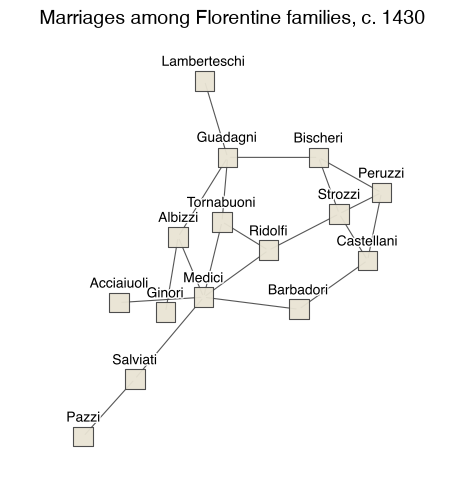

In [18]:
from datachart.constants import ARROW_STYLE, LINE_MARKER

NetworkChart(
    data=marriages,
    label_position=NODE_LABEL_POSITION.ABOVE,
    style={
        # straight, darker edges
        "plot_network_edge_style": ARROW_STYLE.STRAIGHT,
        "plot_network_edge_color": "#444444",
        "plot_network_edge_alpha": 0.9,
        # square markers in one color, with a dark stroke
        "plot_network_node_marker": LINE_MARKER.SQUARE,
        "plot_network_node_color": "#e9e4d4",
        "plot_network_node_edge_color": "#444444",
    },
    title="Marriages among Florentine families, c. 1430",
    figsize=FIG_SIZE.SQUARE,
).show()

A curved edge bows by `plot_network_edge_curve` (0.2 by default). A larger bow keeps the edges of a dense network apart, a negative one bows them to the other side, and `0` draws them straight:

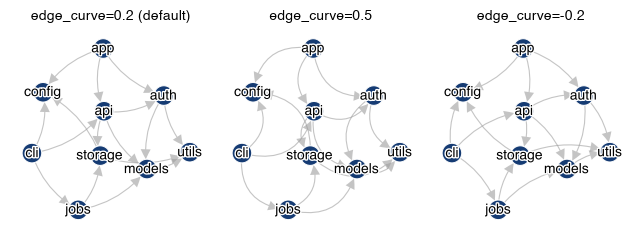

In [19]:
NetworkChart(
    data=[import_edges] * 3,
    subtitle=["edge_curve=0.2 (default)", "edge_curve=0.5", "edge_curve=-0.2"],
    # one style per subplot; None keeps the default
    style=[None, {"plot_network_edge_curve": 0.5}, {"plot_network_edge_curve": -0.2}],
    directed=True,
    max_cols=3,
    figsize=(6.3, 2.6),
).show()

### Text annotations

A highlighted node shows *who*; a note says *why*. `texts` places text on the chart, with an optional `target` that draws a connector to a point ([TextSettingAttrs](../../../references/typings/#datachart.typings.TextSettingAttrs)). The layout spans 0-1 in both directions, so `x`, `y` and `target` are positions in the drawing; under the fixed layout the positions of the nodes are known, so a note can point at one. The [Text Annotations](../../utility/annotations/) guide covers placement and styling. The note below points at the Medici, at the top of the rows.

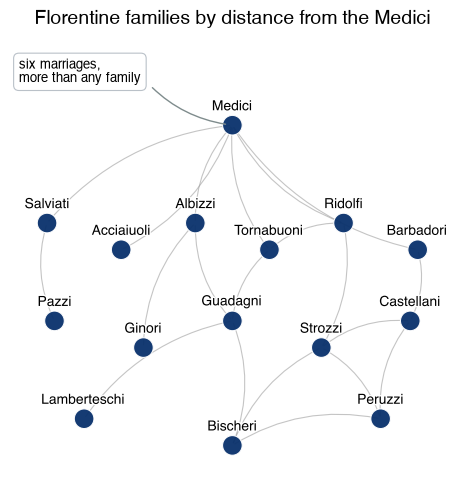

In [20]:
NetworkChart(
    data=levels,
    layout=NETWORK_LAYOUT.FIXED,
    label_position=NODE_LABEL_POSITION.ABOVE,
    # a note beside the Medici, pointing at them
    texts={
        "text": "six marriages,\nmore than any family",
        "x": 0.02,
        "y": 0.92,
        "target": (0.5, 0.8),
    },
    title="Florentine families by distance from the Medici",
    figsize=FIG_SIZE.SQUARE,
).show()

## Multiple Network Charts

### Subplots

Comparing two networks side by side shows what changed between them. A list of networks in `data` draws each in its own subplot; networks never share one drawing, so the subplots are implied. `subtitle` titles each network, `title` stays global, `max_cols` limits the subplots per row, and `style` takes one dictionary per network. The example removes the Medici and their marriages. Both networks use the fixed rows from [Layouts](#layouts), so the families stay in place and only the missing ties change: the Acciaiuoli, the Salviati and the Pazzi are cut off from the rest.

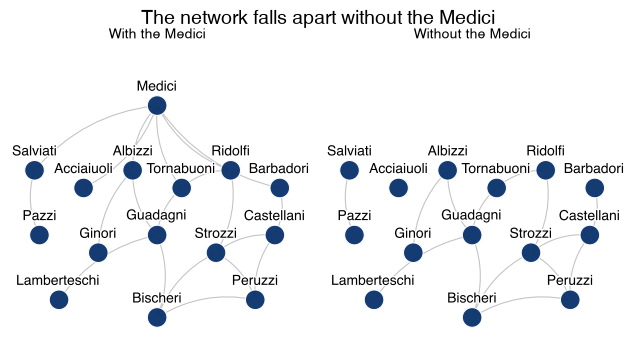

In [21]:
without_medici = {
    # the same positions; a family without a tie stays in the drawing
    "nodes": [node for node in levels["nodes"] if node["id"] != "Medici"],
    "edges": [edge for edge in marriages["edges"] if "Medici" not in (edge["source"], edge["target"])],
}

NetworkChart(
    # one network per subplot
    data=[levels, without_medici],
    subtitle=["With the Medici", "Without the Medici"],
    layout=NETWORK_LAYOUT.FIXED,
    label_position=NODE_LABEL_POSITION.ABOVE,
    max_cols=2,
    title="The network falls apart without the Medici",
    figsize=(6.3, 3.4),
).show()

### Composing network charts

A network shows the structure; a second chart puts numbers to it. A network owns its axes, and its layout space is not a coordinate space another chart can share, so [datachart.utils.Panel](../../../references/utils/#datachart.utils.Panel) rejects a network figure. [datachart.utils.Grid](../../../references/utils/#datachart.utils.Grid) arranges it beside other charts, each in its own cell and with the layout it was drawn with; a `layout_spec` gives a cell more than one column, and the [Grid](../../utility/grid/) guide covers the other layout options. The example sets the bridge roles from [Emphasis](#emphasis), drawn on the fixed rows, beside a [BarChart](../../../references/charts/barchart/#datachart.charts.BarChart) of the ties per family, the Medici highlighted in both.

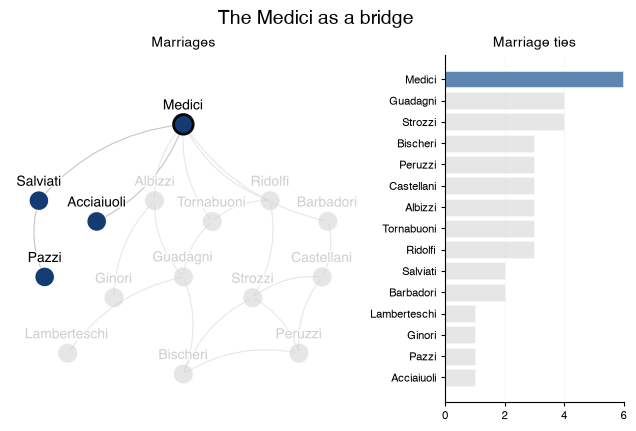

In [22]:
from datachart.charts import BarChart
from datachart.constants import ORIENTATION, SHOW_GRID

network = NetworkChart(
    # the bridge roles on the fixed rows
    data={"nodes": [{**node, "emphasis": role(node["id"])} for node in levels["nodes"]], "edges": marriages["edges"]},
    layout=NETWORK_LAYOUT.FIXED,
    label_position=NODE_LABEL_POSITION.ABOVE,
    title="Marriages",
)
ties = BarChart(
    # fewest first, so the most ties end up at the top
    data=[
        {"label": family, "y": TIES[family], "emphasis": "highlight" if family == "Medici" else "background"}
        for family in sorted(TIES, key=TIES.get)
    ],
    orientation=ORIENTATION.HORIZONTAL,
    title="Marriage ties",
    show_grid=SHOW_GRID.X,
    xmin=0,
)

# the network across two columns, the bars in the third
Grid(
    [
        {"figure": network, "layout_spec": {"row": 0, "col": 0, "rowspan": 1, "colspan": 2}},
        {"figure": ties, "layout_spec": {"row": 0, "col": 2, "rowspan": 1, "colspan": 1}},
    ],
    title="The Medici as a bridge",
    figsize=(6.3, 4.2),
).show()

## Additional Features

### Themes

A theme sets the palette, the node strokes, the fonts and even the label position of every chart at once, which is the way to restyle a whole document. Apply one with [datachart.config.Config.set_theme](../../../references/config/#datachart.config.Config.set_theme) and a [THEME](../../../references/constants/#datachart.constants.THEME) member, as the [Themes](../../styling/themes/) guide shows; the [Theme Gallery](../../styling/theme-gallery/) shows every chart under each theme. Style is resolved when the chart is created, so a theme set before the call and reset after it applies to that chart alone. The `QUILL` theme prints the node names above the markers without being asked.

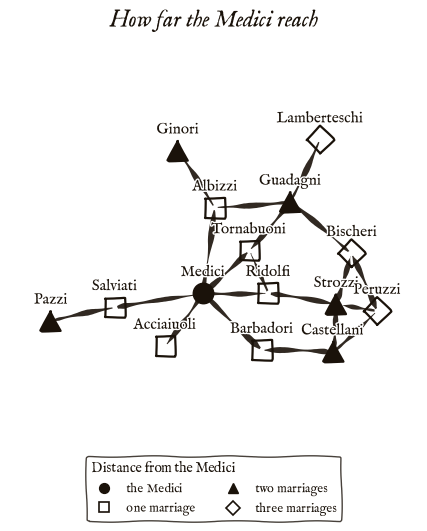

In [23]:
from datachart.config import config
from datachart.constants import THEME

config.set_theme(THEME.QUILL)
figure = NetworkChart(
    data=by_step,
    show_legend=True,
    legend={"title": "Distance from the Medici", "location": LEGEND_LOCATION.OUTSIDE_BOTTOM, "ncols": 2},
    title="How far the Medici reach",
    figsize=(4.8, 5.2),
)
config.reset_config()
figure.show()

## Real-World Examples

The examples below put the features above to work, each one answering a question about who connects to whom. Their data is illustrative, written by hand in hidden cells; each example says what its data stands for.

### Example 1: Who Reviews Whose Code? (Undirected, Grouped Layout, Sizes, and a Highlight)

`REVIEWERS` and `REVIEW_PAIRS` hold a quarter of code reviews in an illustrative engineering department of eight people in three teams. An edge joins two people who reviewed each other's pull requests, weighted by how many reviews they exchanged, and a person's `size` is the number of reviews they gave. Reviews flow both ways, so the network is undirected. The question is whether the teams review only among themselves. The grouped layout draws one cluster per team, placed by how much the teams review each other, the edge widths show the heavy pairs, and the one person who reviews across every team is highlighted.

In [24]:
# an illustrative quarter of code reviews: person -> (team, reviews given)
REVIEWERS = {
    "Ana": ("Backend", 41), "Bo": ("Backend", 18), "Cy": ("Backend", 12),
    "Di": ("Frontend", 33), "Ed": ("Frontend", 15), "Flo": ("Frontend", 9),
    "Gus": ("Data", 27), "Hal": ("Data", 11),
}
# (person, person, reviews exchanged)
REVIEW_PAIRS = [
    ("Ana", "Bo", 14), ("Ana", "Cy", 6), ("Bo", "Cy", 5),
    ("Di", "Ed", 11), ("Di", "Flo", 7), ("Ed", "Flo", 3),
    ("Gus", "Hal", 9),
    ("Ana", "Di", 8), ("Ana", "Gus", 6), ("Ana", "Ed", 2), ("Di", "Gus", 3), ("Bo", "Hal", 1),
]

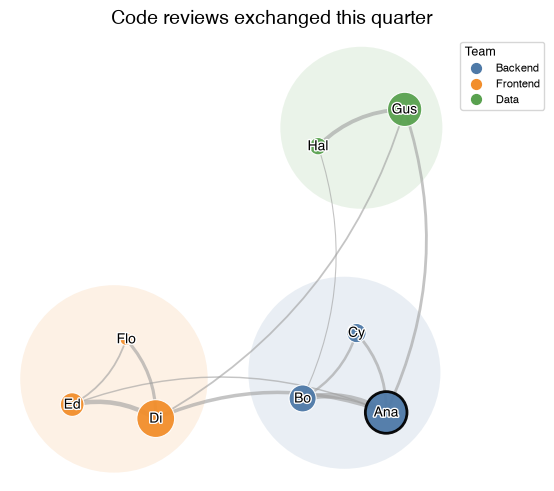

In [25]:
reviews = {
    "nodes": [
        {
            "id": person,
            "group": team,
            "size": given,
            # the reviewer every team leans on
            "emphasis": EMPHASIS.HIGHLIGHT if person == "Ana" else None,
        }
        for person, (team, given) in REVIEWERS.items()
    ],
    "edges": [{"source": a, "target": b, "weight": n} for a, b, n in REVIEW_PAIRS],
}

NetworkChart(
    data=reviews,
    # one cluster per team, the teams placed by how much they review each other
    layout=NETWORK_LAYOUT.GROUPED,
    show_legend=True,
    legend={"title": "Team"},
    title="Code reviews exchanged this quarter",
    figsize=(5.4, 4.8),
).show()

### Example 2: Where Do the Containers Go? (Directed, Edge Values, and a Fixed Layout)

`SHIPMENTS` holds one illustrative month of container shipments between six large ports, in thousands of units, and `PORTS` their rough positions on a world map in the 0-1 layout space. A shipment goes one way, so the network is directed, and a pair of ports trading both ways shows as two arrows. The fixed layout keeps the ports where a reader expects them, so a lane reads as a route, and the values print the volume of each lane with a `"{x:.0f}k"` format. The two ports at the ends of the busiest lane, found from the data, are highlighted.

In [26]:
# rough map positions of six ports in the 0-1 layout space
PORTS = {
    "Shanghai": (0.92, 0.72), "Singapore": (0.8, 0.22), "Dubai": (0.58, 0.45),
    "Rotterdam": (0.42, 0.84), "Los Angeles": (0.05, 0.55), "Santos": (0.28, 0.08),
}
# one illustrative month of shipments: (from, to, thousand containers)
SHIPMENTS = [
    ("Shanghai", "Rotterdam", 96), ("Rotterdam", "Shanghai", 41),
    ("Shanghai", "Los Angeles", 88), ("Los Angeles", "Shanghai", 37),
    ("Shanghai", "Singapore", 52), ("Singapore", "Dubai", 30), ("Dubai", "Rotterdam", 27),
    ("Singapore", "Rotterdam", 44), ("Santos", "Rotterdam", 18), ("Santos", "Shanghai", 22),
    ("Rotterdam", "Santos", 9), ("Los Angeles", "Santos", 7),
]

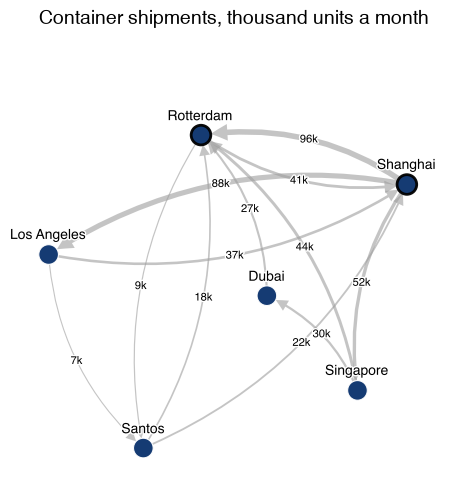

In [27]:
busiest = max(SHIPMENTS, key=lambda shipment: shipment[2])

shipping = {
    "nodes": [
        {
            "id": port,
            "x": x,
            "y": y,
            # the two ends of the busiest lane
            "emphasis": EMPHASIS.HIGHLIGHT if port in busiest[:2] else None,
        }
        for port, (x, y) in PORTS.items()
    ],
    "edges": [{"source": s, "target": t, "weight": n} for s, t, n in SHIPMENTS],
}

NetworkChart(
    data=shipping,
    layout=NETWORK_LAYOUT.FIXED,
    directed=True,
    label_position=NODE_LABEL_POSITION.ABOVE,
    show_values=True,
    value_format="{x:.0f}k",
    title="Container shipments, thousand units a month",
    figsize=FIG_SIZE.SQUARE,
).show()

### Example 3: Which Ports Ship More Than They Receive? (Node Sizes, a Note, and a Grid with a Bar Chart)

The same shipments answer a second question: which ports are net exporters. The network sizes each port by the containers it handles, shipped plus received, and a note points at Shanghai, the largest. A network cannot show by how much a port ships more than it receives, so a grouped [BarChart](../barchart/) of shipped and received containers per port goes beside it, and [Grid](../../utility/grid/) sets the two in one figure. Shanghai, Singapore and Santos ship more than they receive; Rotterdam receives almost four times what it ships.

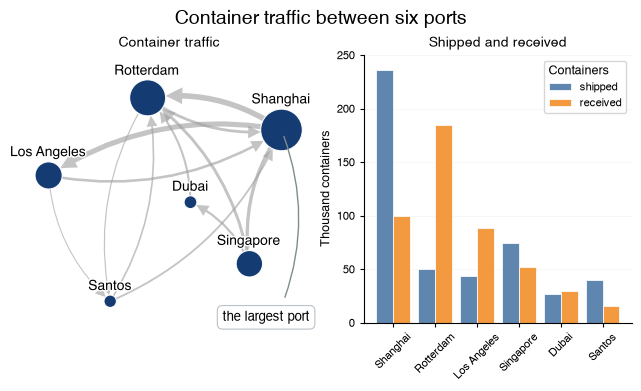

In [28]:
from datachart.constants import BAR_MODE

shipped, received = Counter(), Counter()
for s, t, n in SHIPMENTS:
    shipped[s] += n
    received[t] += n
# the busiest port first
PORT_ORDER = sorted(PORTS, key=lambda port: shipped[port] + received[port], reverse=True)

throughput = NetworkChart(
    data={
        # each port sized by the containers it handles
        "nodes": [
            {"id": port, "x": x, "y": y, "size": shipped[port] + received[port]}
            for port, (x, y) in PORTS.items()
        ],
        "edges": shipping["edges"],
    },
    layout=NETWORK_LAYOUT.FIXED,
    directed=True,
    label_position=NODE_LABEL_POSITION.ABOVE,
    # a note pointing at Shanghai
    texts={"text": "the largest port", "x": 0.7, "y": 0.02, "target": PORTS["Shanghai"]},
    title="Container traffic",
)
balance = BarChart(
    data=[
        [{"label": port, "y": shipped[port]} for port in PORT_ORDER],
        [{"label": port, "y": received[port]} for port in PORT_ORDER],
    ],
    subtitle=["shipped", "received"],
    bar_mode=BAR_MODE.GROUP,
    show_legend=True,
    legend={"title": "Containers"},
    title="Shipped and received",
    ylabel="Thousand containers",
    xtickrotate=45,
    show_grid=SHOW_GRID.Y,
    ymin=0,
)

Grid([[throughput, balance]], title="Container traffic between six ports", figsize=(6.3, 3.8)).show()